# Task 2: Drug-Disease Gene Network Analysis

This notebook demonstrates **Task 2** of the scGVP downstream analysis pipeline: identifying the core genes and pathways through which a drug exerts its effects by combining model-predicted differential expression with STRING protein–protein interaction (PPI) networks.

## Workflow
1. Load the pre-trained GINVAE model and LINCS dataset
2. Process the reference dataset to build biological context
3. Identify differentially expressed genes (DEGs) for a drug
4. Query the STRING database to build a PPI network
5. Detect hub genes using composite centrality scoring
6. Perform pathway enrichment analysis (KEGG / Reactome / GO)
7. Visualize the network and run batch analysis across multiple drugs

## Outputs
- `smiles_conversion.csv` — SMILES → molecular formula mapping
- `drug_*_hub_genes.csv` — ranked hub genes per drug
- `drug_*_enrichment.csv` — pathway enrichment per drug
- `all_hub_genes.csv` / `all_enrichments.csv` — aggregated results
- `drug_*_layouts/` — network visualisation PDFs (Kamada-Kawai & Shell layouts)
- `colorbar.pdf` — standalone log2FC colour legend

## 1. Imports

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import networkx as nx

from model import GINVAE
from dataset import ChunkedGeneGraphDataset
from task2 import DrugDiseaseGeneNetwork

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.9.0.dev20250827+cu129
Device: cuda


## 2. Configuration

Update the paths below to match your local environment.  
Datasets and model weights are available at:  
**https://huggingface.co/datasets/Mike2481/Dataset4scGVP/tree/main**

In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
MODEL_PATH  = '../src/best_gin_vae_model_node_level.pth'
LINCS_PATH  = '../lincs/merged_all_965_with_morgan.h5ad'
TAHOE_PATHS = [f'../minitahoe/p{i}_with_morgan.h5ad' for i in range(1, 15)]
REF_CACHE   = './output/reference_latents.pkl'
SAVE_DIR    = './output/task1_cross_dataset'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('./output', exist_ok=True)

# ── Model hyperparameters (must match training) ───────────────────────────────
INPUT_DIM  = 1
HIDDEN_DIM = 300
LATENT_DIM = 100
NUM_LAYERS = 2

## 3. Load Model

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = GINVAE(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_layers=NUM_LAYERS
).to(device)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Model loaded on {device}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Model loaded on cuda
Total parameters: 728,604


## 4. Load Data

In [6]:
# Load AnnData object for metadata and expression values
lincs_adata = sc.read_h5ad(LINCS_PATH)
print(f"LINCS dataset: {lincs_adata.shape[0]} cells × {lincs_adata.shape[1]} genes")
print(f"Conditions: {lincs_adata.obs['condition'].value_counts().to_dict()}")
print(f"Unique drugs: {lincs_adata.obs['canonical_smiles'].nunique()}")

# Build graph dataset (cached after first run)
lincs_dataset = ChunkedGeneGraphDataset([LINCS_PATH], split='test')
print(f"\nDataset samples: {len(lincs_dataset)}")

LINCS dataset: 157138 cells × 965 genes
Conditions: {'control': 78569, 'perturb': 78569}
Unique drugs: 8316
Found 32 chunks with 157138 total samples

Dataset samples: 157138


## 5. Process Reference Dataset

The GINVAE model transfers perturbation effects from a reference distribution.  
We first process the LINCS dataset to extract control and perturbed latent representations.

In [7]:
print("Processing reference dataset (this may take a few minutes)...")
model.process_reference_dataset(
    x_ref_dataset=lincs_dataset,
    save_path=REF_CACHE,
    force_reprocess=False   # Set True to recompute from scratch
)
print("Reference dataset ready.")

Processing reference dataset (this may take a few minutes)...
Loading existing processed data from ./output/reference_latents.pkl
Loaded reference data metadata from ./output/reference_latents.pkl
Total samples available: 157138
Loading data from chunks...


Loading chunks: 100%|██████████| 16/16 [00:02<00:00,  6.93it/s, file=chunk_15.pkl]


Loaded and filtered 157138 samples from chunks
Computing biological context from 78569 control and 78569 perturb samples
Extracting graph-level latent representations...


Processing perturb samples: 100%|██████████| 78569/78569 [00:01<00:00, 68395.58it/s]


Computing mean representations...
References computed successfully.
Control ref shape: torch.Size([1, 100]), norm: 3.5154
perturb ref shape: torch.Size([1, 100]), norm: 3.5215
Biological context norm: 0.0068
Reference dataset ready.


## 6. Initialise DrugDiseaseGeneNetwork

In [8]:
task2 = DrugDiseaseGeneNetwork(model, device, species=9606)
print("DrugDiseaseGeneNetwork initialised.")

DrugDiseaseGeneNetwork initialised.


## 7. Single Drug Analysis

We select one drug from the LINCS dataset and run a complete analysis:
- DEG identification
- STRING PPI network construction
- Hub gene detection
- Pathway enrichment

In [9]:
# Pick the first available drug
ptrb_col = 'canonical_smiles'
drug_smiles = lincs_adata.obs[ptrb_col].unique()[0]
print(f"Analysing drug SMILES: {drug_smiles[:60]}...")

result = task2.analyze_drug_perturbation(lincs_adata, drug_smiles)

if result is not None:
    print(f"\n=== Analysis Summary ===")
    print(f"Drug name     : {result['drug_name']}")
    print(f"DEGs found    : {len(result['deg_genes'])}")
    print(f"Network nodes : {result['network'].number_of_nodes() if result['network'] else 0}")
    print(f"Network edges : {result['network'].number_of_edges() if result['network'] else 0}")
    if result['hub_genes']:
        print(f"Top hub genes :")
        for gene, score in result['hub_genes'][:10]:
            print(f"  {gene:12s}  score={score:.4f}")

Analysing drug SMILES: BrCC(=O)NCCc1ccc2ccccc2c1...

=== Analyzing drug: C14H14BrNO (MW: 291.0) ===
    SMILES: BrCC(=O)NCCc1ccc2ccccc2c1
Using 1 control and 1 perturbed samples
Computing DEGs from 1 control and 1 perturbed samples...
Data appears to be log-transformed, using direct difference
Only 0 DEGs found with strict criteria, relaxing thresholds...
Still only 0 DEGs, selecting top 20 by fold change
Identified 20 DEGs
  Log2FC range: [-6.563, 5.535]
  Adj. p-value range: [1.000e+00, 1.000e+00]
Querying STRING database for 20 genes...
Mapped 20/20 genes to STRING IDs
Retrieved 4 interactions from STRING
PPI network: 7 nodes, 4 edges

Top 10 Hub Genes:
  TLR4: 0.2533
  MAPK13: 0.1333
  SPP1: 0.1333
  CRK: 0.1167
  EPHB2: 0.1167
  KIF5C: 0.1167
  MAP7: 0.1167
Performing pathway enrichment analysis for 20 genes...
Found 12 enriched terms

Enriched pathways: 12

Top 5 enriched pathways:
category                                      description    fdr
    KEGG                          

In [10]:
# Display enriched pathways
if result is not None and result['enrichment'] is not None:
    print("Top enriched pathways:")
    display(result['enrichment'].nsmallest(10, 'fdr')[['category', 'description', 'fdr', 'n_genes']])
else:
    print("No significant enrichment found or network could not be built.")

Top enriched pathways:


,category,description,fdr,n_genes
0,KEGG,Yersinia infection,0.0025,4
1,KEGG,Toll-like receptor signaling pathway,0.0084,3
2,KEGG,Inflammatory mediator regulation of TRP channels,0.0084,3
3,KEGG,Shigellosis,0.0084,4
4,KEGG,Chagas disease,0.0084,3
5,KEGG,Human cytomegalovirus infection,0.0084,4
6,KEGG,Human immunodeficiency virus 1 infection,0.0084,4
7,KEGG,PD-L1 expression and PD-1 checkpoint pathway i...,0.0084,3
8,KEGG,"Growth hormone synthesis, secretion and action",0.0087,3
9,KEGG,Dopaminergic synapse,0.0097,3


## 8. Visualise the PPI Network

We generate the PPI network for the selected drug using multiple graph layouts.

In [11]:
if result is not None and result['network'] is not None and result['network'].number_of_nodes() > 0:
    layout_dir = os.path.join(SAVE_DIR, 'single_drug_layouts')
    task2.visualize_network_all_layouts(
        G=result['network'],
        hub_genes=result['hub_genes'],
        deg_genes=result['deg_genes'],
        log2fc=result['log2fc'],
        save_dir=layout_dir,
        drug_name=result['drug_name']
    )
    print(f"Network figures saved to: {layout_dir}")
else:
    print("No network to visualise.")


Generating kamada_kawai layout...
Network visualization saved to ./output/task1_cross_dataset/single_drug_layouts/network_kamada_kawai.pdf

Generating shell layout...
Network visualization saved to ./output/task1_cross_dataset/single_drug_layouts/network_shell.pdf
Colorbar saved to ./output/task1_cross_dataset/single_drug_layouts/colorbar.pdf

All layouts saved to ./output/task1_cross_dataset/single_drug_layouts/
Network figures saved to: ./output/task1_cross_dataset/single_drug_layouts


## 9. Inline Network Preview

Quick inline visualisation using NetworkX and matplotlib (spring layout, smaller figure).

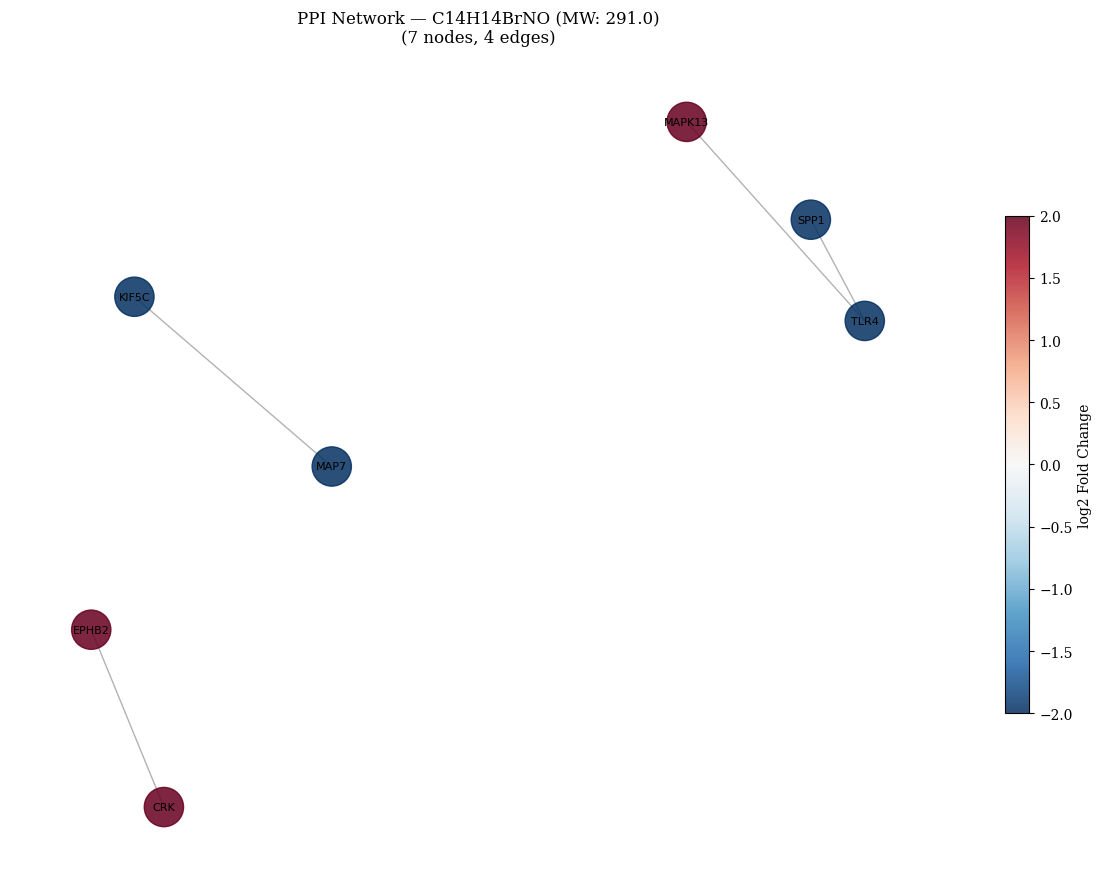

In [12]:
if result is not None and result['network'] is not None and result['network'].number_of_nodes() > 0:
    G = result['network']
    hub_names = [g for g, _ in result['hub_genes'][:10]] if result['hub_genes'] else []
    gene_to_fc = dict(zip(result['deg_genes'], result['log2fc']))

    # Limit to top 80 nodes for inline display
    if G.number_of_nodes() > 80:
        degrees = dict(G.degree())
        top_nodes = sorted(degrees, key=lambda n: degrees[n], reverse=True)[:80]
        G_vis = G.subgraph(top_nodes).copy()
    else:
        G_vis = G

    pos = nx.spring_layout(G_vis, seed=42, k=0.8)
    node_colors = [gene_to_fc.get(n, 0) for n in G_vis.nodes()]
    node_sizes  = [800 if n in hub_names else 200 for n in G_vis.nodes()]

    fig, ax = plt.subplots(figsize=(12, 9))
    nx.draw_networkx_edges(G_vis, pos, alpha=0.3, width=1, ax=ax)
    sc_nodes = nx.draw_networkx_nodes(
        G_vis, pos, node_color=node_colors, node_size=node_sizes,
        cmap=plt.cm.RdBu_r, vmin=-2, vmax=2, alpha=0.85, ax=ax
    )
    labels = {n: n for n in hub_names if n in G_vis.nodes()}
    nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8, ax=ax)
    plt.colorbar(sc_nodes, ax=ax, label='log2 Fold Change', shrink=0.6)
    ax.set_title(f"PPI Network — {result['drug_name'][:50]}\n"
                 f"({G_vis.number_of_nodes()} nodes, {G_vis.number_of_edges()} edges)",
                 fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'single_drug_preview.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No network to preview.")

## 10. Batch Analysis — Multiple Drugs

Analyse multiple drugs in batch mode. Results are saved per drug and aggregated into summary CSVs.

In [13]:
batch_dir = os.path.join(SAVE_DIR, 'batch_results')

summary_df = task2.batch_analyze_drugs(
    adata=lincs_adata,
    n_drugs=5,       # Number of drugs to analyse
    save_dir=batch_dir
)

print("\n=== Batch Analysis Summary ===")
display(summary_df)

SMILES conversion table saved to ./output/task1_cross_dataset/batch_results/smiles_conversion.csv
Colorbar saved to ./output/task1_cross_dataset/batch_results/colorbar.pdf

Processing drug 1/5

=== Analyzing drug: C14H14BrNO (MW: 291.0) ===
    SMILES: BrCC(=O)NCCc1ccc2ccccc2c1
Using 1 control and 1 perturbed samples
Computing DEGs from 1 control and 1 perturbed samples...
Data appears to be log-transformed, using direct difference
Only 0 DEGs found with strict criteria, relaxing thresholds...
Still only 0 DEGs, selecting top 20 by fold change
Identified 20 DEGs
  Log2FC range: [-6.563, 5.535]
  Adj. p-value range: [1.000e+00, 1.000e+00]
Querying STRING database for 20 genes...
Mapped 20/20 genes to STRING IDs
Retrieved 4 interactions from STRING
PPI network: 7 nodes, 4 edges

Top 10 Hub Genes:
  TLR4: 0.2533
  MAPK13: 0.1333
  SPP1: 0.1333
  CRK: 0.1167
  EPHB2: 0.1167
  KIF5C: 0.1167
  MAP7: 0.1167
Performing pathway enrichment analysis for 20 genes...
Found 12 enriched terms

Enrich

,drug_id,drug_name,n_degs,n_network_nodes,n_network_edges,top_hub,n_enriched_pathways,n_control_samples,n_perturbed_samples
0,BrCC(=O)NCCc1ccc2ccccc2c1,C14H14BrNO (MW: 291.0),20,7,4,TLR4,12,1,1
1,Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53,C19H16BrNO2 (MW: 369.0),20,2,1,TRIB3,0,4,4
2,Brc1ccc(Cn2cncc2Cn2cc(C(=O)N3CCOCC3)c(c2)-c2cc...,C30H27BrN4O2 (MW: 554.1),20,11,12,CDC25A,0,29,29
3,Brc1ccc(cc1)-c1csc(n1)N1CCNCC1,C13H14BrN3S (MW: 323.0),20,10,8,UBQLN2,0,3,3
4,Brc1cccc(Nc2ncnc3ccc(NC(=O)C=C)cc23)c1,C17H13BrN4O (MW: 368.0),20,11,19,CCNA2,5,10,10


In [14]:
# Load and display aggregated hub genes
all_hubs_path = os.path.join(batch_dir, 'all_hub_genes.csv')
if os.path.exists(all_hubs_path):
    all_hubs_df = pd.read_csv(all_hubs_path)
    print(f"Total hub gene entries: {len(all_hubs_df)}")
    print("\nTop hub genes across drugs:")
    display(all_hubs_df.head(20))
else:
    print("Hub gene CSV not found.")

Total hub gene entries: 41

Top hub genes across drugs:


,rank,gene,hub_score,log2fc,padj,drug_name,drug_smiles
0,1,TLR4,0.253333,-2.721575,1.000000,C14H14BrNO (MW: 291.0),BrCC(=O)NCCc1ccc2ccccc2c1
1,2,MAPK13,0.133333,4.093500,1.000000,C14H14BrNO (MW: 291.0),BrCC(=O)NCCc1ccc2ccccc2c1
2,3,SPP1,0.133333,-4.443174,1.000000,C14H14BrNO (MW: 291.0),BrCC(=O)NCCc1ccc2ccccc2c1
3,4,CRK,0.116667,3.745450,1.000000,C14H14BrNO (MW: 291.0),BrCC(=O)NCCc1ccc2ccccc2c1
4,5,EPHB2,0.116667,5.534525,1.000000,C14H14BrNO (MW: 291.0),BrCC(=O)NCCc1ccc2ccccc2c1
5,6,KIF5C,0.116667,-3.320700,1.000000,C14H14BrNO (MW: 291.0),BrCC(=O)NCCc1ccc2ccccc2c1
6,7,MAP7,0.116667,-4.054451,1.000000,C14H14BrNO (MW: 291.0),BrCC(=O)NCCc1ccc2ccccc2c1
7,1,TRIB3,0.700000,1.435220,0.998003,C19H16BrNO2 (MW: 369.0),Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53
8,2,CHAC1,0.700000,1.628149,0.998003,C19H16BrNO2 (MW: 369.0),Brc1cc2OCOc2cc1C3Nc4ccccc4C5C=CCC53
9,1,CDC25A,0.377692,-0.645694,0.755868,C30H27BrN4O2 (MW: 554.1),Brc1ccc(Cn2cncc2Cn2cc(C(=O)N3CCOCC3)c(c2)-c2cc...


In [15]:
# Load and display aggregated pathway enrichment
all_enrich_path = os.path.join(batch_dir, 'all_enrichments.csv')
if os.path.exists(all_enrich_path):
    all_enrich_df = pd.read_csv(all_enrich_path)
    print(f"Total enrichment entries: {len(all_enrich_df)}")
    print("\nTop enriched pathways across drugs:")
    display(all_enrich_df.nsmallest(20, 'fdr')[['drug_name', 'category', 'description', 'fdr', 'n_genes']])
else:
    print("Enrichment CSV not found.")

Total enrichment entries: 17

Top enriched pathways across drugs:


,drug_name,category,description,fdr,n_genes
12,C17H13BrN4O (MW: 368.0),KEGG,Cellular senescence,0.00013,5
13,C17H13BrN4O (MW: 368.0),KEGG,Cell cycle,0.00110,4
0,C14H14BrNO (MW: 291.0),KEGG,Yersinia infection,0.00250,4
1,C14H14BrNO (MW: 291.0),KEGG,Toll-like receptor signaling pathway,0.00840,3
4,C14H14BrNO (MW: 291.0),KEGG,Chagas disease,0.00840,3
5,C14H14BrNO (MW: 291.0),KEGG,Human cytomegalovirus infection,0.00840,4
2,C14H14BrNO (MW: 291.0),KEGG,Inflammatory mediator regulation of TRP channels,0.00840,3
3,C14H14BrNO (MW: 291.0),KEGG,Shigellosis,0.00840,4
7,C14H14BrNO (MW: 291.0),KEGG,PD-L1 expression and PD-1 checkpoint pathway i...,0.00840,3
6,C14H14BrNO (MW: 291.0),KEGG,Human immunodeficiency virus 1 infection,0.00840,4


## 11. Summary Plot — Number of DEGs and Enriched Pathways per Drug

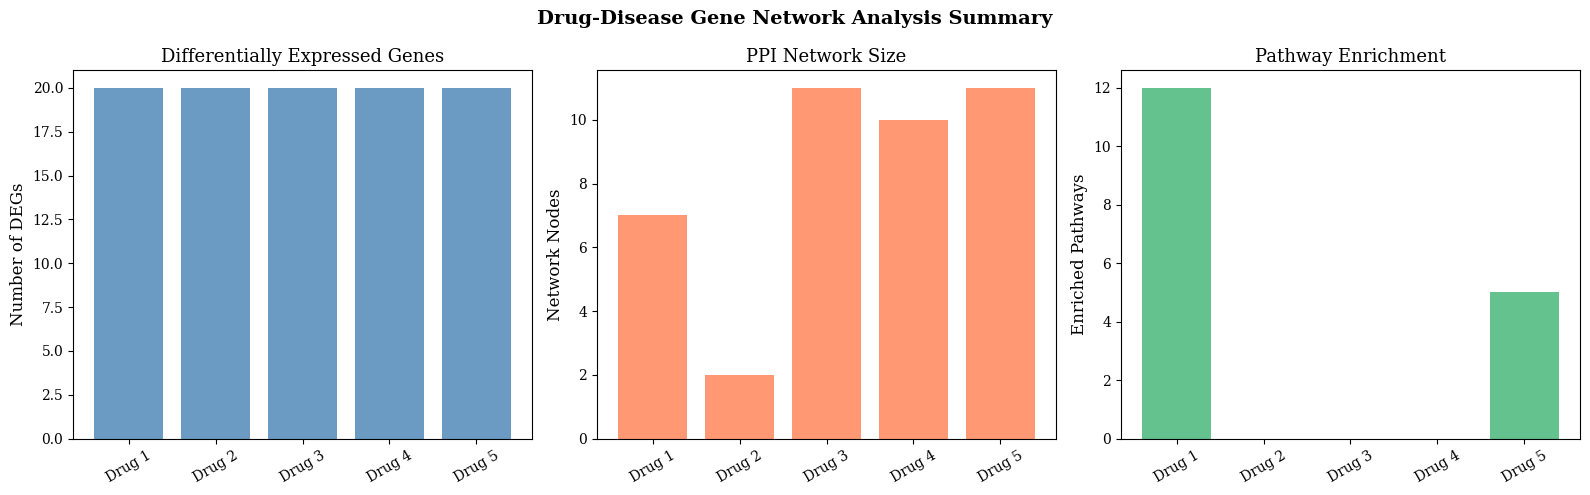

In [16]:
if len(summary_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    drug_labels = [f"Drug {i+1}" for i in range(len(summary_df))]

    axes[0].bar(drug_labels, summary_df['n_degs'], color='steelblue', alpha=0.8)
    axes[0].set_ylabel('Number of DEGs', fontsize=12)
    axes[0].set_title('Differentially Expressed Genes', fontsize=13)
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(drug_labels, summary_df['n_network_nodes'], color='coral', alpha=0.8)
    axes[1].set_ylabel('Network Nodes', fontsize=12)
    axes[1].set_title('PPI Network Size', fontsize=13)
    axes[1].tick_params(axis='x', rotation=30)

    axes[2].bar(drug_labels, summary_df['n_enriched_pathways'], color='mediumseagreen', alpha=0.8)
    axes[2].set_ylabel('Enriched Pathways', fontsize=12)
    axes[2].set_title('Pathway Enrichment', fontsize=13)
    axes[2].tick_params(axis='x', rotation=30)

    plt.suptitle('Drug-Disease Gene Network Analysis Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'batch_summary.png'), dpi=150, bbox_inches='tight')
    plt.show()